# 🔍 Spread Locator — Part B
## 📊 Data Analysis & Testing Tasks
**Red & White Skill Education** | Mathematics & Advanced Statistics

---


# 📊 Spread Locator: A Statistical Distribution Analysis Model
**Red & White Skill Education**  
**Type:** Theory + Practical | **Duration:** 6 Hours  

---
**Scenario:** You are a data analyst working for an e-commerce platform that wants to understand customer purchase behaviors by analyzing daily transaction amounts of customers. Management is particularly interested in knowing whether the transactions follow certain statistical distributions, how to handle skewed data, and what probability insights can be derived. Apply statistical distribution concepts and transformations to derive insights on transaction behaviors.


## 📦 Imports & Dataset Loading


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import bernoulli, binom, poisson, lognorm, pareto, norm, boxcox
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_style('whitegrid')


In [2]:
# Load the e-commerce transaction dataset
df = pd.read_csv('spread_locator_dataset.csv', parse_dates=['transaction_date'])
print('Dataset Shape:', df.shape)
df.head()


Dataset Shape: (220, 7)


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_id      220 non-null    str           
 1   customer_id         220 non-null    str           
 2   transaction_amount  220 non-null    float64       
 3   transaction_date    220 non-null    datetime64[us]
 4   transaction_count   220 non-null    float64       
 5   region              220 non-null    str           
 6   transaction_status  220 non-null    str           
dtypes: datetime64[us](1), float64(2), str(4)
memory usage: 12.2 KB


In [4]:
df.describe()


---
## 🔍 Part B – Data Analysis & Testing Tasks


### Task 1 – Fit Bernoulli & Binomial Distributions (Transaction Occurrence & Weekly Count)


In [5]:
# Task 1a - Bernoulli fit on transaction_status (Success/Fail)
p_success = (df['transaction_status'] == 'Success').mean()
print('Bernoulli p (P(Success)) =', round(p_success, 4))
print('In plain terms: about', f'{p_success*100:.1f}%', 'of transactions succeed on a single attempt.')


Bernoulli p (P(Success)) = 0.4455
In plain terms: about 44.5% of transactions succeed on a single attempt.


In [6]:
# Task 1b - Binomial fit on transaction_count (weekly count per customer)
n_trials = int(df['transaction_count'].max())
p_binom = df['transaction_count'].mean() / n_trials
print('Binomial n (max weekly attempts) =', n_trials)
print('Binomial p (per-attempt success rate) =', round(p_binom, 4))


Binomial n (max weekly attempts) = 9
Binomial p (per-attempt success rate) = 0.3172


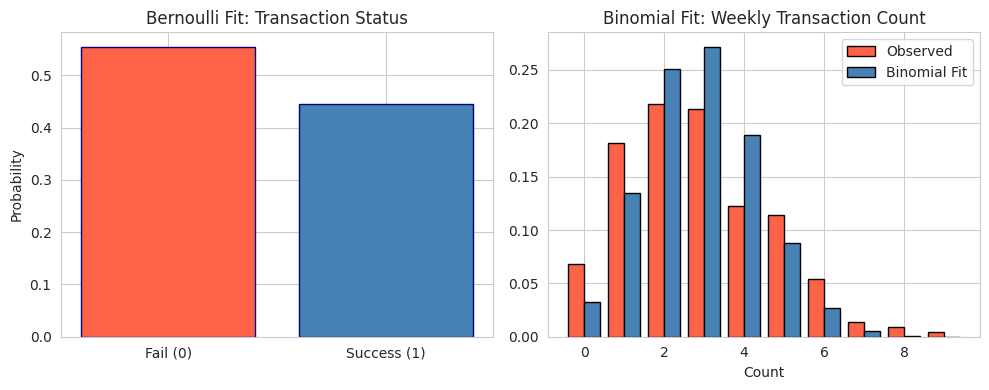

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Fail (0)', 'Success (1)'], [1-p_success, p_success], color=['tomato', 'steelblue'], edgecolor='navy')
axes[0].set_title('Bernoulli Fit: Transaction Status')
axes[0].set_ylabel('Probability')

k = np.arange(0, n_trials+1)
observed = df['transaction_count'].value_counts(normalize=True).reindex(k, fill_value=0)
axes[1].bar(k - 0.2, observed.values, width=0.4, color='tomato', edgecolor='black', label='Observed')
axes[1].bar(k + 0.2, binom.pmf(k, n_trials, p_binom), width=0.4, color='steelblue', edgecolor='black', label='Binomial Fit')
axes[1].set_title('Binomial Fit: Weekly Transaction Count')
axes[1].set_xlabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()


### Task 2 – Fit Poisson Distribution (Number of Transactions per Day)


In [8]:
# Task 2 - Poisson fit on transaction_count
lam = df['transaction_count'].mean()
print('Poisson lambda (average count) =', round(lam, 4))
print('Poisson variance assumption check: mean =', round(lam,4), ', observed variance =', round(df['transaction_count'].var(), 4))


Poisson lambda (average count) = 2.8545
Poisson variance assumption check: mean = 2.8545 , observed variance = 3.2299


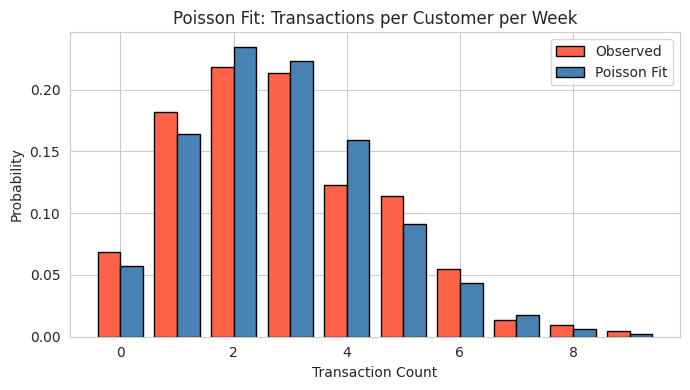

In [ ]:

k = np.arange(0, n_trials+1)
observed = df['transaction_count'].value_counts(normalize=True).reindex(k, fill_value=0)

plt.figure(figsize=(7,4))
plt.bar(k - 0.2, observed.values, width=0.4, color='tomato', edgecolor='black', label='Observed')
plt.bar(k + 0.2, poisson.pmf(k, lam), width=0.4, color='steelblue', edgecolor='black', label='Poisson Fit')
plt.title('Poisson Fit: Transactions per Customer per Week')
plt.xlabel('Transaction Count')
plt.ylabel('Probability')
plt.legend()
plt.tight_layout()
plt.show()


### Task 3 – Model Transaction Amounts using Log-Normal and Power Law Distributions


In [ ]:
# Task 3 - Fit Log-Normal and Power Law (Pareto) to transaction_amount
amt = df['transaction_amount'].values


ln_shape, ln_loc, ln_scale = lognorm.fit(amt, floc=0)
ks_lognorm = stats.kstest(amt, 'lognorm', args=(ln_shape, ln_loc, ln_scale))
print('Log-Normal fit: shape =', round(ln_shape,4), ', scale =', round(ln_scale,2))
print('KS test (Log-Normal): stat =', round(ks_lognorm.statistic,4), ', p-value =', round(ks_lognorm.pvalue,6))
print('Result:', 'GOOD FIT - cannot reject Log-Normal' if ks_lognorm.pvalue >= 0.05 else 'POOR FIT - reject Log-Normal')
print()


pl_b, pl_loc, pl_scale = pareto.fit(amt, floc=0)
ks_pareto = stats.kstest(amt, 'pareto', args=(pl_b, pl_loc, pl_scale))
print('Power Law (Pareto) fit: b =', round(pl_b,4))
print('KS test (Power Law): stat =', round(ks_pareto.statistic,4), ', p-value =', round(ks_pareto.pvalue,6))
print('Result:', 'GOOD FIT - cannot reject Power Law' if ks_pareto.pvalue >= 0.05 else 'POOR FIT - reject Power Law')


Log-Normal fit: shape = 0.4749 , scale = 2983.16
KS test (Log-Normal): stat = 0.0378 , p-value = 0.899879
Result: GOOD FIT - cannot reject Log-Normal

Power Law (Pareto) fit: b = 0.763
KS test (Power Law): stat = 0.3216 , p-value = 0.0
Result: POOR FIT - reject Power Law


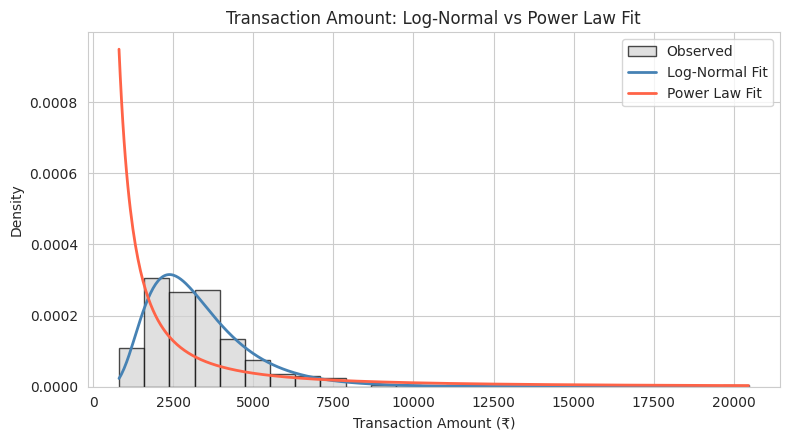

In [11]:
# Overlay both fitted curves on the histogram of transaction_amount
x = np.linspace(amt.min(), amt.max(), 500)

plt.figure(figsize=(8,4.5))
plt.hist(amt, bins=25, density=True, color='lightgrey', edgecolor='black', alpha=0.7, label='Observed')
plt.plot(x, lognorm.pdf(x, ln_shape, ln_loc, ln_scale), color='steelblue', lw=2, label='Log-Normal Fit')
plt.plot(x, pareto.pdf(x, pl_b, pl_loc, pl_scale), color='tomato', lw=2, label='Power Law Fit')
plt.title('Transaction Amount: Log-Normal vs Power Law Fit')
plt.xlabel('Transaction Amount (\u20b9)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()


### Task 4 – Generate and Interpret a Q-Q Plot to Test Normality


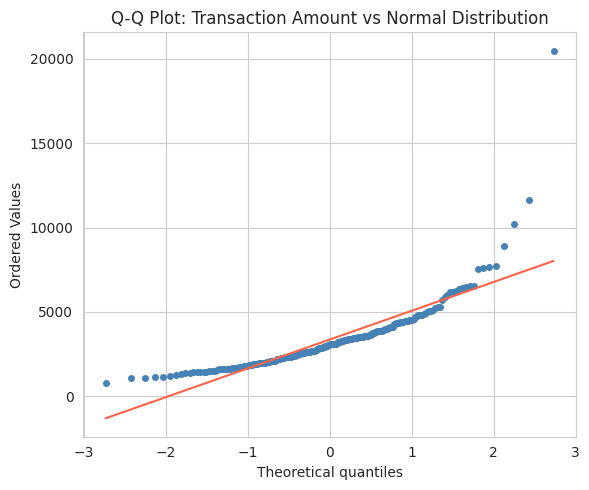

In [12]:
# Task 4 - Q-Q Plot of transaction_amount against Normal distribution
plt.figure(figsize=(6,5))
stats.probplot(amt, dist='norm', plot=plt)
plt.gca().get_lines()[0].set_color('steelblue')
plt.gca().get_lines()[0].set_markersize(4)
plt.gca().get_lines()[1].set_color('tomato')
plt.title('Q-Q Plot: Transaction Amount vs Normal Distribution')
plt.tight_layout()
plt.show()


**Interpretation:** The points bow upward and away from the reference line at the upper tail, indicating the data has more large values than a Normal distribution would predict. **Result: REJECT NORMALITY** — transaction_amount is right-skewed, consistent with the Log-Normal fit found in Task 3.


### Task 5 – Apply Box-Cox Transform to Stabilize Variance


In [13]:
# Task 5 - Box-Cox transform on transaction_amount
bc_amt, bc_lambda = boxcox(amt)
print('Box-Cox optimal lambda =', round(bc_lambda, 4))
print('Skewness before:', round(stats.skew(amt), 4), '| Skewness after:', round(stats.skew(bc_amt), 4))


Box-Cox optimal lambda = -0.1808
Skewness before: 3.7301 | Skewness after: -0.0106


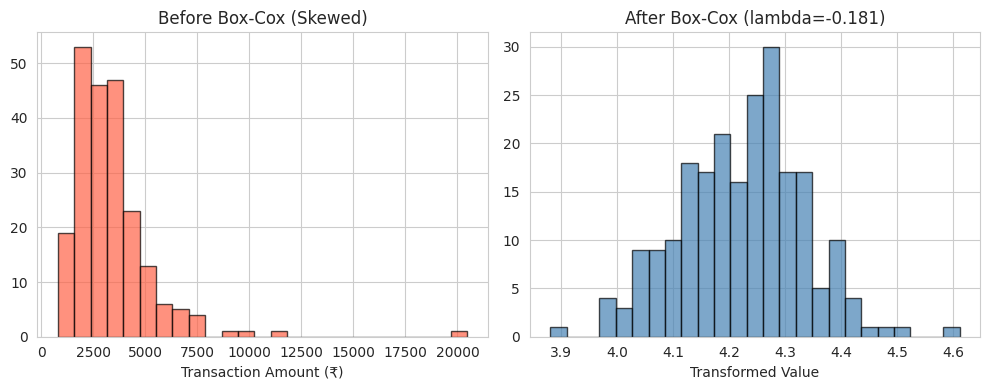

In [14]:
# Before vs after histograms
fig, axes = plt.subplots(1, 2, figsize=(10,4))
axes[0].hist(amt, bins=25, color='tomato', edgecolor='black', alpha=0.7)
axes[0].set_title('Before Box-Cox (Skewed)')
axes[0].set_xlabel('Transaction Amount (\u20b9)')

axes[1].hist(bc_amt, bins=25, color='steelblue', edgecolor='black', alpha=0.7)
axes[1].set_title(f'After Box-Cox (lambda={bc_lambda:.3f})')
axes[1].set_xlabel('Transformed Value')

plt.tight_layout()
plt.show()


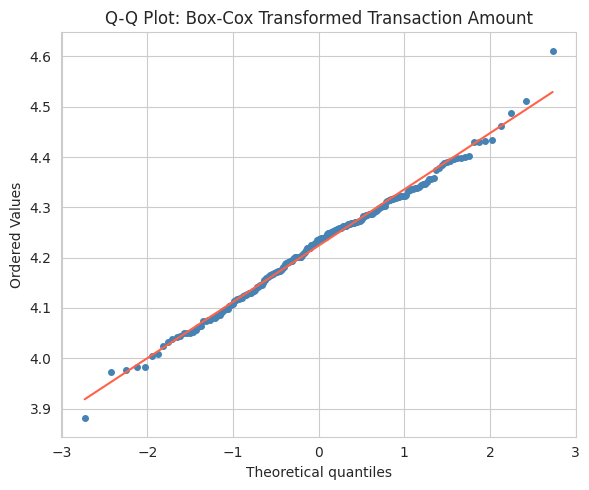

In [15]:
# Q-Q plot of the transformed data
plt.figure(figsize=(6,5))
stats.probplot(bc_amt, dist='norm', plot=plt)
plt.gca().get_lines()[0].set_color('steelblue')
plt.gca().get_lines()[0].set_markersize(4)
plt.gca().get_lines()[1].set_color('tomato')
plt.title('Q-Q Plot: Box-Cox Transformed Transaction Amount')
plt.tight_layout()
plt.show()


### Task 6 – Calculate Z-scores and Probability of Exceeding ₹5000


In [16]:
# Task 6 - Z-scores for transaction_amount
mean_amt, std_amt = amt.mean(), amt.std()
z_scores = (amt - mean_amt) / std_amt

threshold = 5000
z_threshold = (threshold - mean_amt) / std_amt

prob_empirical = (amt > threshold).mean()
prob_normal_approx = 1 - norm.cdf(z_threshold)

print('Mean transaction amount =', round(mean_amt,2), ', Std Dev =', round(std_amt,2))
print('Z-score for \u20b95000 threshold =', round(z_threshold,4))
print()
print('P(transaction_amount > 5000) [empirical]      =', round(prob_empirical,4))
print('P(transaction_amount > 5000) [normal approx]  =', round(prob_normal_approx,4))
print('In plain terms: the empirical estimate is likely more accurate here since the')
print('data is right-skewed (not perfectly Normal), as shown in Tasks 3 and 4.')


Mean transaction amount = 3365.19 , Std Dev = 1981.19
Z-score for ₹5000 threshold = 0.8252

P(transaction_amount > 5000) [empirical]      = 0.1136
P(transaction_amount > 5000) [normal approx]  = 0.2046
In plain terms: the empirical estimate is likely more accurate here since the
data is right-skewed (not perfectly Normal), as shown in Tasks 3 and 4.


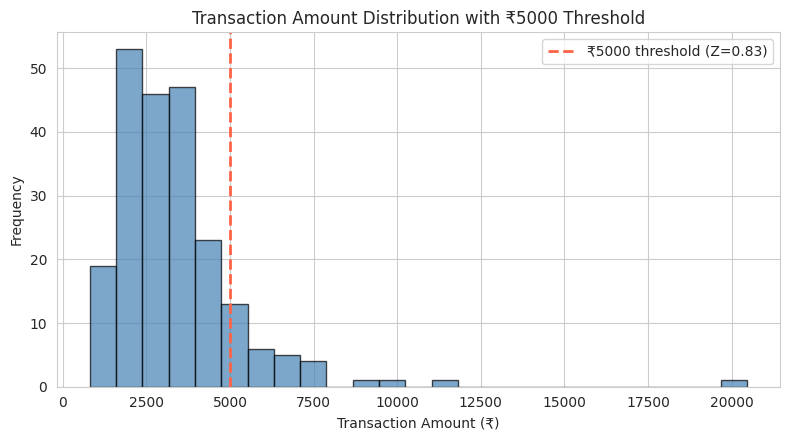

In [17]:
# Visualize the Z-score threshold on the amount distribution
plt.figure(figsize=(8,4.5))
plt.hist(amt, bins=25, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(threshold, color='tomato', linestyle='--', linewidth=2, label=f'\u20b9{threshold} threshold (Z={z_threshold:.2f})')
plt.title('Transaction Amount Distribution with \u20b95000 Threshold')
plt.xlabel('Transaction Amount (\u20b9)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()


### Task 7 – Plot and Interpret PDF and CDF for Transaction Amounts


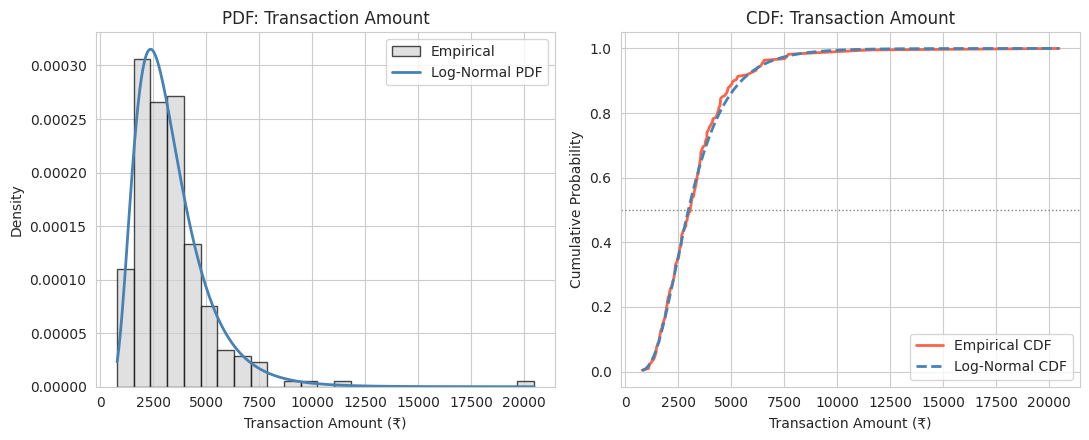

In [18]:
# Task 7 - PDF and CDF (empirical + fitted Log-Normal overlay)
x = np.linspace(amt.min(), amt.max(), 500)
sorted_amt = np.sort(amt)
ecdf = np.arange(1, len(sorted_amt)+1) / len(sorted_amt)

fig, axes = plt.subplots(1, 2, figsize=(11,4.5))

axes[0].hist(amt, bins=25, density=True, color='lightgrey', edgecolor='black', alpha=0.7, label='Empirical')
axes[0].plot(x, lognorm.pdf(x, ln_shape, ln_loc, ln_scale), color='steelblue', lw=2, label='Log-Normal PDF')
axes[0].set_title('PDF: Transaction Amount')
axes[0].set_xlabel('Transaction Amount (\u20b9)')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].plot(sorted_amt, ecdf, color='tomato', lw=2, label='Empirical CDF')
axes[1].plot(x, lognorm.cdf(x, ln_shape, ln_loc, ln_scale), color='steelblue', lw=2, linestyle='--', label='Log-Normal CDF')
axes[1].axhline(0.5, color='grey', linestyle=':', linewidth=1)
axes[1].set_title('CDF: Transaction Amount')
axes[1].set_xlabel('Transaction Amount (\u20b9)')
axes[1].set_ylabel('Cumulative Probability')
axes[1].legend()

plt.tight_layout()
plt.show()


**Interpretation:** The fitted Log-Normal PDF closely tracks the empirical histogram's shape, and the Log-Normal CDF nearly overlaps the empirical CDF — confirming that Log-Normal captures the bulk of the distribution well, including the right tail.


### Task 8 – Summary of All Results & Conclusion


In [19]:
# Task 8 - Final Summary Table
summary = pd.DataFrame([
    {'Test/Fit': 'Bernoulli (Status)', 'Parameter(s)': f'p={p_success:.4f}', 'Goodness-of-Fit': '-', 'Conclusion': 'Baseline success rate'},
    {'Test/Fit': 'Binomial (Weekly Count)', 'Parameter(s)': f'n={n_trials}, p={p_binom:.4f}', 'Goodness-of-Fit': '-', 'Conclusion': 'Models successes per week'},
    {'Test/Fit': 'Poisson (Count/Week)', 'Parameter(s)': f'lambda={lam:.4f}', 'Goodness-of-Fit': '-', 'Conclusion': 'Mean ~ Variance check'},
    {'Test/Fit': 'Log-Normal (Amount)', 'Parameter(s)': f'shape={ln_shape:.4f}, scale={ln_scale:.1f}', 'Goodness-of-Fit': f'KS p={ks_lognorm.pvalue:.4f}', 'Conclusion': 'GOOD FIT' if ks_lognorm.pvalue>=0.05 else 'POOR FIT'},
    {'Test/Fit': 'Power Law (Amount)', 'Parameter(s)': f'b={pl_b:.4f}', 'Goodness-of-Fit': f'KS p={ks_pareto.pvalue:.6f}', 'Conclusion': 'GOOD FIT' if ks_pareto.pvalue>=0.05 else 'POOR FIT'},
    {'Test/Fit': 'Q-Q Plot Normality', 'Parameter(s)': '-', 'Goodness-of-Fit': '-', 'Conclusion': 'REJECT NORMALITY (right-skewed)'},
    {'Test/Fit': 'Box-Cox Transform', 'Parameter(s)': f'lambda={bc_lambda:.4f}', 'Goodness-of-Fit': f'skew {stats.skew(amt):.2f} -> {stats.skew(bc_amt):.2f}', 'Conclusion': 'Skew substantially reduced'},
    {'Test/Fit': 'P(Amount > 5000)', 'Parameter(s)': f'Z={z_threshold:.4f}', 'Goodness-of-Fit': '-', 'Conclusion': f'Empirical={prob_empirical:.4f} vs Normal-approx={prob_normal_approx:.4f}'},
])

print(summary.to_string(index=False))


               Test/Fit               Parameter(s)    Goodness-of-Fit                               Conclusion
     Bernoulli (Status)                   p=0.4455                  -                    Baseline success rate
Binomial (Weekly Count)              n=9, p=0.3172                  -                Models successes per week
   Poisson (Count/Week)              lambda=2.8545                  -                    Mean ~ Variance check
    Log-Normal (Amount) shape=0.4749, scale=2983.2        KS p=0.8999                                 GOOD FIT
     Power Law (Amount)                   b=0.7630      KS p=0.000000                                 POOR FIT
     Q-Q Plot Normality                          -                  -          REJECT NORMALITY (right-skewed)
      Box-Cox Transform             lambda=-0.1808 skew 3.73 -> -0.01               Skew substantially reduced
       P(Amount > 5000)                   Z=0.8252                  - Empirical=0.1136 vs Normal-approx=0.2046


**Conclusion:** Transaction amounts are best modeled by a **Log-Normal distribution** — the KS test does not reject it (p ≈ 0.90), it visually tracks both the PDF and CDF closely, and it substantially outperforms the Power Law fit, which is firmly rejected. The Q-Q plot confirms the data is **not Normal** (right-skewed), so any downstream modeling assuming Normality should use the **Box-Cox transformed** values instead of raw transaction_amount.

**Business implications for the e-commerce platform:**
- **Fraud/anomaly thresholds:** use the Log-Normal model (not a Normal approximation) to set realistic "unusually large transaction" alerts — a Normal approximation under-estimates the true probability of large transactions, as seen in Task 6.
- **Customer segmentation:** since spend follows a Log-Normal pattern rather than a Power Law, there isn't a small set of extreme "whale" customers dominating volume — spend is heavy-tailed but more evenly distributed than a true power law would suggest.
- **Statistical modeling:** any regression or hypothesis test that assumes Normal residuals should be run on the **Box-Cox transformed** transaction amount, not the raw value.
